In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

wine = load_wine()

X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=1,
    stratify=y
)

forest = RandomForestClassifier(
    n_estimators=500,
    random_state=1
)

# 1. Train a Random Forest classifier.
forest.fit(X_train, y_train)
print(X_train.shape)
print(forest.score(X_test, y_test))

# 2. Extract feature importances.
importances = forest.feature_importances_
print(importances)
print(len(importances))
print(importances.sum())

feature_names = wine.feature_names
print(feature_names)

# 3. Match each importance with its feature name.
for name, importance in zip(feature_names, importances):
    print(name, importance)

(124, 13)
1.0
[0.13822434 0.03085574 0.00873805 0.0299998  0.02513494 0.05823566
 0.14612287 0.01154759 0.0257134  0.15315771 0.07752497 0.114818
 0.17992694]
13
1.0
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
alcohol 0.13822434128388703
malic_acid 0.030855737083571706
ash 0.00873805181485404
alcalinity_of_ash 0.02999980079201223
magnesium 0.02513494158344364
total_phenols 0.058235657900474025
flavanoids 0.14612286806893526
nonflavanoid_phenols 0.011547594195815256
proanthocyanins 0.025713395711502687
color_intensity 0.1531577060918445
hue 0.07752497212441119
od280/od315_of_diluted_wines 0.11481799554990077
proline 0.17992693779934774


In [ ]:
import numpy as np

# 4. Rank features from most important to least important.
indices = np.argsort(importances)[::-1]

# 5. Interpret feature importance correctly.
for i in indices:
    print(
        feature_names[i],
        importances[i]
    )

proline 0.17992693779934774
color_intensity 0.1531577060918445
flavanoids 0.14612286806893526
alcohol 0.13822434128388703
od280/od315_of_diluted_wines 0.11481799554990077
hue 0.07752497212441119
total_phenols 0.058235657900474025
malic_acid 0.030855737083571706
alcalinity_of_ash 0.02999980079201223
proanthocyanins 0.025713395711502687
magnesium 0.02513494158344364
nonflavanoid_phenols 0.011547594195815256
ash 0.00873805181485404


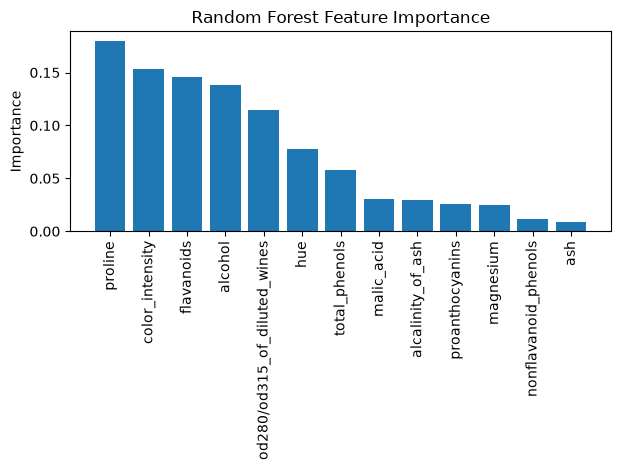

In [8]:
import matplotlib.pyplot as plt

plt.bar(
    range(len(importances)),
    importances[indices]
)

plt.xticks(
    range(len(importances)),
    [feature_names[i] for i in indices],
    rotation=90
)

plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()